In [73]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

print("Libraries imported successfully.")

Libraries imported successfully.


In [74]:
PROJECT_ROOT = Path("../../").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "biomarkers" / "zheen"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "eda" / "zheen"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset directory:", DATA_DIR)
print("Artifact directory:", ARTIFACT_DIR)

Dataset directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\biomarkers\zheen
Artifact directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\zheen


In [75]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV file found in: {DATA_DIR}"
    )

print("CSV files found:")

for i, file in enumerate(csv_files):
    print(f"{i}: {file.name}")

DATA_FILE = csv_files[0]

print("\nUsing:", DATA_FILE.name)

CSV files found:
0: Medicaldataset.csv

Using: Medicaldataset.csv


In [76]:
zheen_raw = pd.read_csv(DATA_FILE)

print(f"Rows    : {zheen_raw.shape[0]:,}")
print(f"Columns : {zheen_raw.shape[1]:,}")

display(zheen_raw.head())

Rows    : 1,319
Columns : 9


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,63,1,66,160,83,160.0,1.80,0.012,negative
1,20,1,94,98,46,296.0,6.75,1.060,positive
2,56,1,64,160,77,270.0,1.99,0.003,negative
3,66,1,70,120,55,270.0,13.87,0.122,positive
4,54,1,64,112,65,300.0,1.08,0.003,negative


In [77]:
schema = pd.DataFrame({
    "column": zheen_raw.columns,
    "dtype": zheen_raw.dtypes.astype(str).values,
    "unique_values": [
        zheen_raw[col].nunique(dropna=True)
        for col in zheen_raw.columns
    ]
})

display(schema)

,column,dtype,unique_values
0,Age,int64,75
1,Gender,int64,2
2,Heart rate,int64,79
3,Systolic blood pressure,int64,116
4,Diastolic blood pressure,int64,73
5,Blood sugar,float64,244
6,CK-MB,float64,700
7,Troponin,float64,352
8,Result,object,2


In [78]:
missing = zheen_raw.isna().sum()

quality = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": (missing / len(zheen_raw) * 100).round(2)
})

display(quality)

print(f"Duplicate rows: {zheen_raw.duplicated().sum():,}")

,missing_count,missing_percent
Age,0,0.0
Gender,0,0.0
Heart rate,0,0.0
Systolic blood pressure,0,0.0
Diastolic blood pressure,0,0.0
Blood sugar,0,0.0
CK-MB,0,0.0
Troponin,0,0.0
Result,0,0.0


Duplicate rows: 0


,count,percentage
Result,,
positive,810,61.41
negative,509,38.59


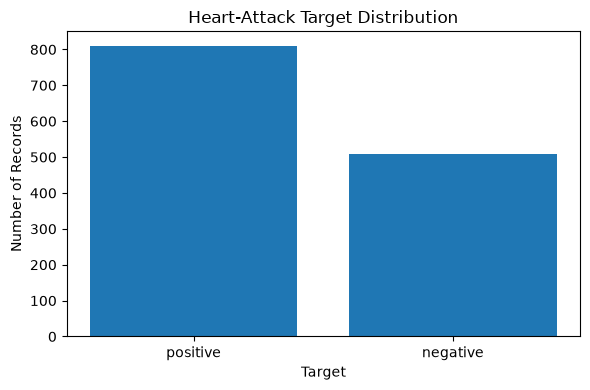

In [79]:
target_column = "Result"

target_counts = zheen_raw[target_column].value_counts(dropna=False)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": (target_counts / len(zheen_raw) * 100).round(2)
})

display(target_summary)

plt.figure(figsize=(6, 4))

plt.bar(
    target_summary.index.astype(str),
    target_summary["count"]
)

plt.title("Heart-Attack Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [80]:
numeric_columns = [
    "Age",
    "Heart rate",
    "Systolic blood pressure",
    "Diastolic blood pressure",
    "Blood sugar",
    "CK-MB",
    "Troponin",
]

numeric_summary = zheen_raw[numeric_columns].describe().T

display(
    numeric_summary[
        ["count", "mean", "std", "min", "50%", "max"]
    ].round(2)
)

,count,mean,std,min,50%,max
Age,1319.0,56.19,13.64,14.00,58.00,103.0
Heart rate,1319.0,78.34,51.63,20.00,74.00,1111.0
Systolic blood pressure,1319.0,127.17,26.12,42.00,124.00,223.0
Diastolic blood pressure,1319.0,72.27,14.03,38.00,72.00,154.0
Blood sugar,1319.0,146.63,74.92,35.00,116.00,541.0
CK-MB,1319.0,15.27,46.33,0.32,2.85,300.0
Troponin,1319.0,0.36,1.15,0.00,0.01,10.3


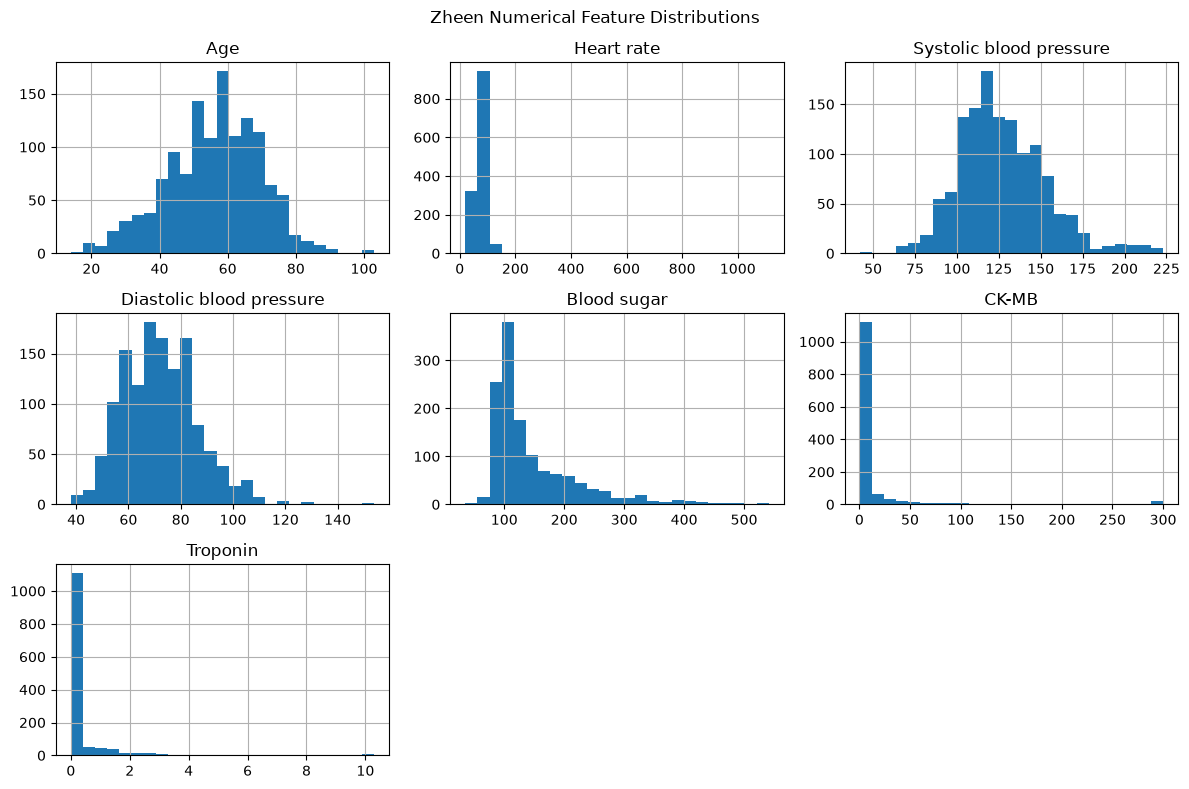

In [81]:
zheen_raw[numeric_columns].hist(
    figsize=(12, 8),
    bins=25
)

plt.suptitle("Zheen Numerical Feature Distributions")
plt.tight_layout()
plt.show()

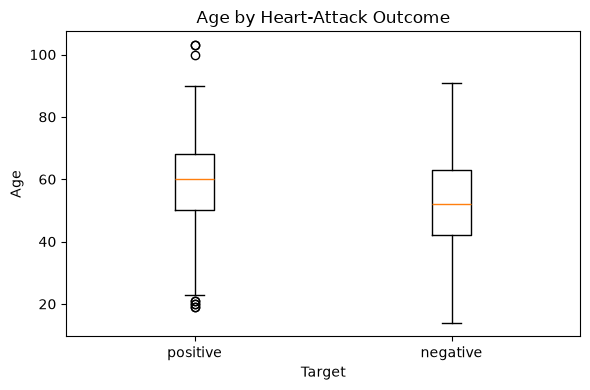

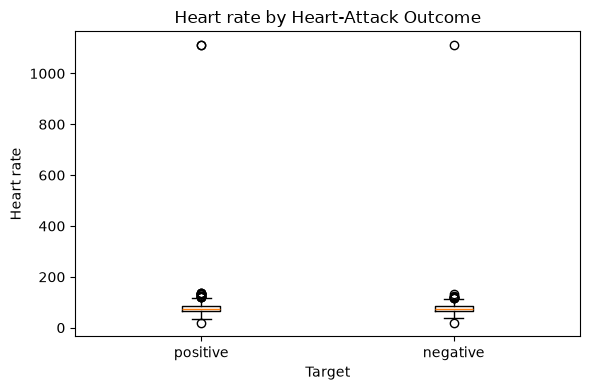

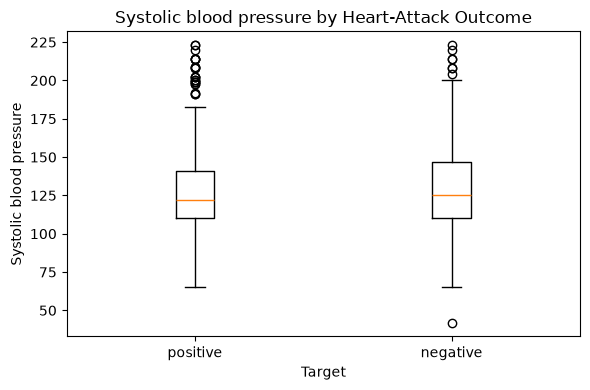

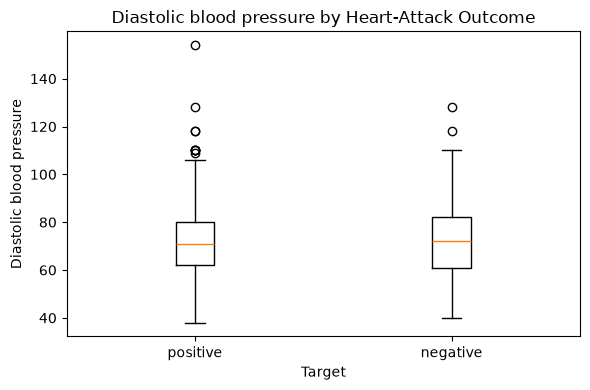

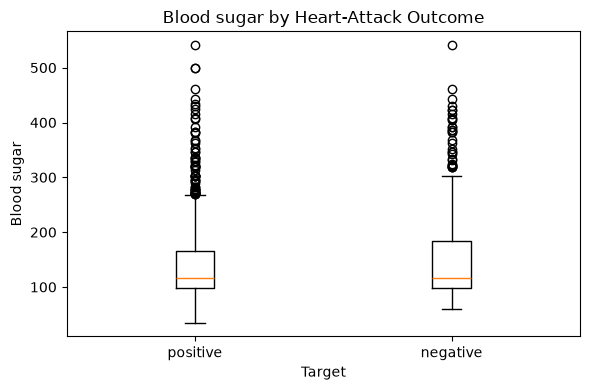

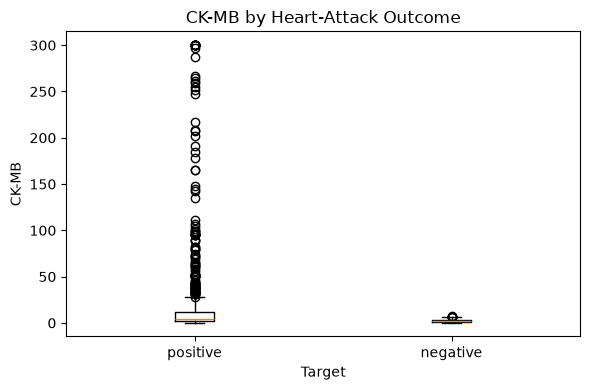

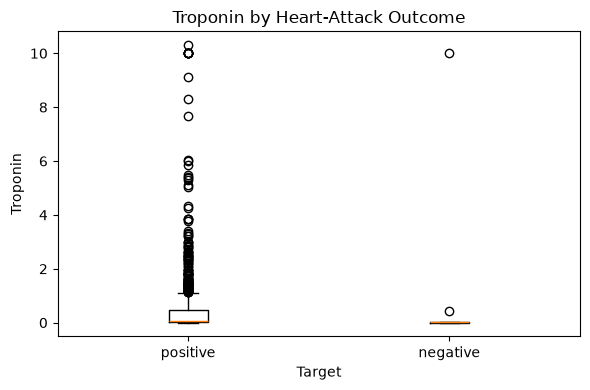

In [82]:
for column in numeric_columns:

    groups = [
        zheen_raw.loc[
            zheen_raw[target_column] == target_value,
            column
        ].dropna()
        for target_value in target_counts.index
    ]

    plt.figure(figsize=(6, 4))

    plt.boxplot(
        groups,
        tick_labels=[str(value) for value in target_counts.index]
    )

    plt.title(f"{column} by Heart-Attack Outcome")
    plt.xlabel("Target")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [83]:
eda_summary = {
    "dataset": "Zheen Heart Attack Dataset",
    "rows": int(len(zheen_raw)),
    "columns": int(zheen_raw.shape[1]),
    "missing_values": int(zheen_raw.isna().sum().sum()),
    "duplicate_rows": int(zheen_raw.duplicated().sum()),
    "target_counts": {
        str(k): int(v)
        for k, v in target_counts.items()
    }
}

pd.DataFrame([eda_summary]).to_json(
    ARTIFACT_DIR / "eda_summary.json",
    orient="records",
    indent=2
)

numeric_summary[
    ["count", "mean", "std", "min", "50%", "max"]
].round(2).to_csv(
    ARTIFACT_DIR / "numeric_summary.csv"
)

target_summary.to_csv(
    ARTIFACT_DIR / "target_distribution.csv"
)

print("EDA completed successfully.")
print("\nSummary:")
print(eda_summary)

EDA completed successfully.

Summary:
{'dataset': 'Zheen Heart Attack Dataset', 'rows': 1319, 'columns': 9, 'missing_values': 0, 'duplicate_rows': 0, 'target_counts': {'positive': 810, 'negative': 509}}
